In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
os.environ["JAX_PLATFORM_NAME"] = "cpu"
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

In [8]:
import h5py, os, tqdm, glob
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph, data

# print(jax.devices("gpu"))
print(jax.default_backend())

cpu


# configuration

In [4]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

i_snapshots = [-1]

In [5]:
out_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

cosmo = out_dict["cosmo"]
scale = out_dict["scales"]

dm_pos = out_dict["dm_poss"]
dm_vel = out_dict["dm_vels"]

gas_pos = out_dict["gas_poss"]
gas_vel = out_dict["gas_vels"]

Found matching catalogs
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 1/1 [00:02<00:00,  2.45s/it]


Found 14787 duplicate gas particle IDs
There are 15915546 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 1/1 [00:16<00:00, 16.61s/it]


In [34]:
particle_inputs = data.get_simplified_hpm_inputs(
    scale,
    gas_pos,
    gas_vel,
    mesh_shape,
)

N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

In [39]:
particle_inputs.shape

(262144, 5)

In [35]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, None, -1), out_axes=-1)

field_inputs = vcic_paint(jnp.zeros(mesh_shape), gas_pos, particle_inputs/gas_N[:,jnp.newaxis])

(array([79726., 28991., 29059., 31132., 32634., 29644., 20712.,  8380.,
         1738.,   128.]),
 array([0.        , 0.19670312, 0.39340624, 0.59010935, 0.78681248,
        0.98351562, 1.1802187 , 1.37692189, 1.57362497, 1.77032816,
        1.96703124]),
 <BarContainer object of 10 artists>)

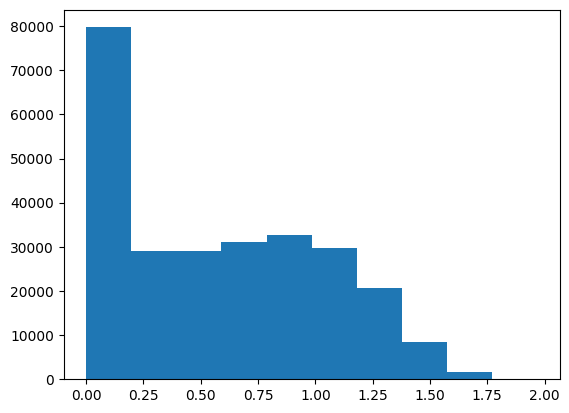

In [38]:
plt.hist(field_inputs[...,0].ravel())

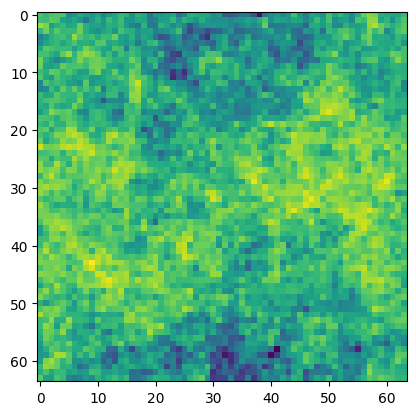

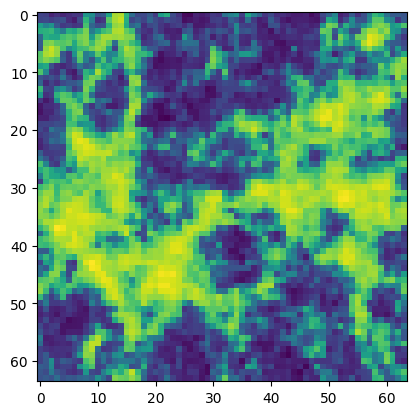

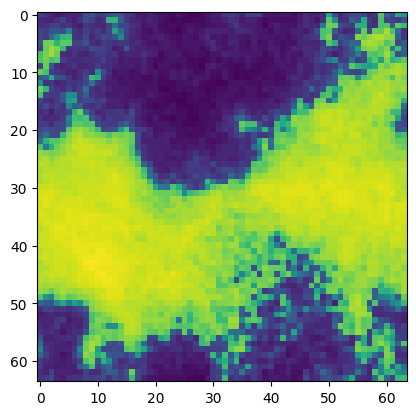

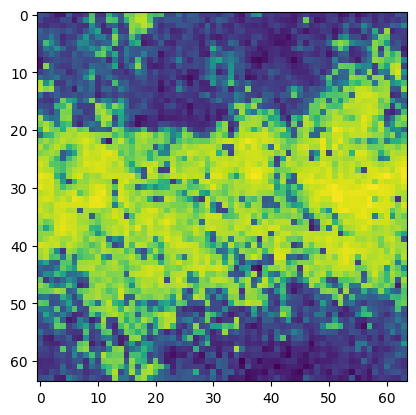

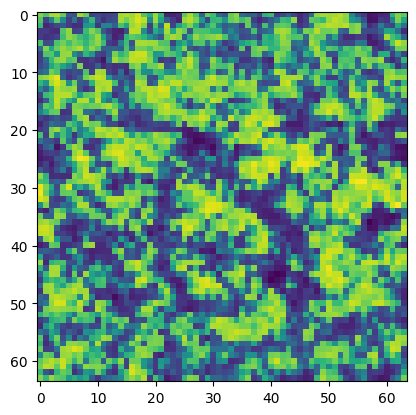

In [36]:
for i in range(field_inputs.shape[-1]):
    field = field_inputs[...,i]
    field = field.sum(axis=0)
    field = jnp.arcsinh(field)
    
    fig, ax = plt.subplots()

    ax.imshow(field)

In [42]:
# particle_ones = jnp.ones(gas_pos.shape[0])

N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

field_ones = cic_paint(jnp.zeros(mesh_shape), gas_pos, 1/gas_N)

(array([79726., 28991., 29059., 31132., 32634., 29644., 20712.,  8380.,
         1738.,   128.]),
 array([0.        , 0.19670312, 0.39340624, 0.59010935, 0.78681248,
        0.98351562, 1.1802187 , 1.37692189, 1.57362497, 1.77032816,
        1.96703124]),
 <BarContainer object of 10 artists>)

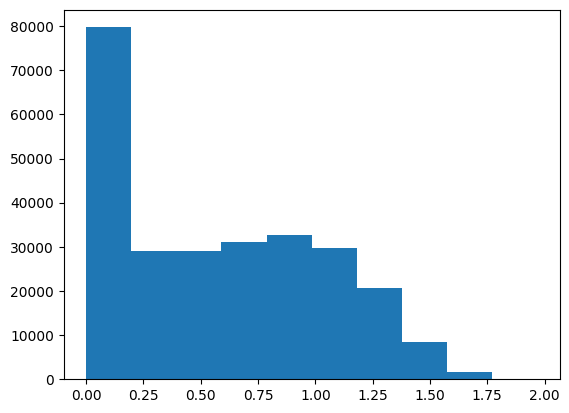

In [45]:
plt.hist(field_ones.ravel())

In [44]:
field_ones.shape

(64, 64, 64)

In [41]:
particle_ones.shape

(262144,)

In [23]:
gas_N.shape

(262144,)

In [24]:
gas_inputs.shape

(262144, 5)

In [25]:
temp = gas_inputs[:,1:]/gas_N[:,jnp.newaxis]

In [26]:
temp

Array([[ 0.06580679,  0.1642934 ,  0.01573357,  0.01807623],
       [ 0.13415772,  0.4400758 ,  0.11786608, -0.09581256],
       [-0.13207482,  0.24494411,  0.23566179, -0.18952884],
       ...,
       [ 0.1461726 ,  0.5679504 , -0.13202699, -0.24613003],
       [ 0.15152386,  1.1918004 ,  0.3929414 , -0.6684424 ],
       [ 0.15330575,  0.76240486,  0.16316499,  0.06255803]],      dtype=float32)

In [ ]:
gas

In [ ]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, None, -1), out_axes=-1)
gasvcic_read(jnp.zeros(mesh_shape), gas_pos, gas_inputs/gas_N[:,jnp.newaxis]